In [1]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.Fare.describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [7]:
df.Fare.median()

14.4542

## The Fare column is right-skewed since the mean is much higher than the median. This indicates the presence of high-value outliers, which is confirmed by the large difference between the 75th percentile and the maximum value.

In [8]:
q99=df['Fare'].quantile(0.99)

In [9]:
q99

249.00622000000035

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [17]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [18]:
df['Age'].fillna(df['Age'].median(),inplace=True)

C:\Users\krise\AppData\Local\Temp\ipykernel_35288\1527141296.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


In [19]:
df['Age'].isnull().sum()

0

In [22]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

C:\Users\krise\AppData\Local\Temp\ipykernel_35288\3717664479.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


In [23]:
df['Embarked'].isnull().sum()

0

In [24]:
df.drop('Cabin',axis=1,inplace=True)

In [25]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [26]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [27]:
q1=df['Fare'].quantile(0.25)

In [28]:
q1

7.9104

In [29]:
q3=df['Fare'].quantile(0.75)
q3

31.0

In [30]:
IQR=q3-q1
IQR

23.0896

In [31]:
lower_bound=q1-1.5*IQR
upper_bound=q3+1.5*IQR

In [32]:
outliers=df[(df['Fare']<lower_bound)&(df['Fare']>upper_bound)]
outliers.shape[0]

0

In [34]:
q99=df['Fare'].quantile(0.99)
q99

249.00622000000035

In [35]:
df['Fare']=df['Fare'].clip(upper=q99)

In [39]:
survival_by_gender=df.groupby('Sex')['Survived'].mean()
survival_by_gender

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

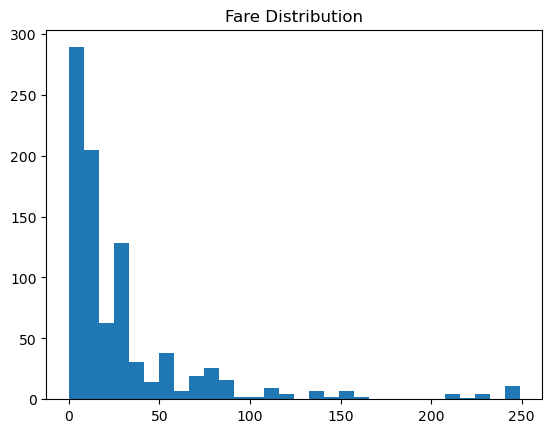

In [42]:
plt.hist(df['Fare'], bins=30)
plt.title("Fare Distribution")
plt.show()